# 01 · Carbon pools: seasonal patterns and environmental associations

The introduction and literature review frame the study around soil, vegetation and
phytoplankton carbon in Loktak and Pumlen lakes. This notebook visualises measured
variation and associations; carbon stock is not a measurement of sequestration rate.

**Sources:** `Scatter Plot.xlsx` and `PCA.xlsx`, interpreted alongside
`Chapter 1-Introduction.docx` and `Chapter 2- Review of literature.docx`.
The supplied ChatGPT response is context; all numerical results below come from the workbooks.

Run **Kernel → Restart Kernel and Run All Cells** using **Python (ler)**, with this notebook
in `ipynb_files_1/`, and the three Excel files and `ecological_data.py` in the parent project folder. Each notebook runs independently.
Figures are displayed here and saved as 300-dpi PNGs and vector PDFs under `ipynb_files_1/figures/`.
The source workbooks are read only. Tables are saved under `ipynb_files_1/tables/`.

## Research context and scientific objective

The thesis compares **Loktak and Pumlen**, two freshwater wetlands of the Manipur Valley, over **2022–2023**. The principal ecological question is how their hydrological and physicochemical conditions relate to carbon held in wetland soils and biological pools. The literature review emphasises water-level changes, plant productivity, nutrient cycling and organic-matter decomposition as potential mechanisms. These mechanisms motivate the plots but **cannot be inferred causally from correlations alone**.

**Data structure.** Each water and soil worksheet contains 80 observations (2 wetlands × 2 years × 4 seasons × 5 sites). The same site identifiers recur across seasons and years; do not treat 80 records as independent replicates for hypothesis testing. The notebooks provide exploratory, descriptive graphics, not a repeated-measures inferential model.

**Data caveats.** `Scatter Plot.xlsx` contains a site-level block headed *Total Biomass Carbon* whose numeric values exactly match water TDS. It is excluded from site-level TBC calculations. The separate **TBC seasonal means** in `Line_Graph` are displayed as *reported summaries only*, with their `±` spread measure unconfirmed. Phytoplankton carbon units also require confirmation. The scatter workbook is arranged as hand-formatted blocks, so matching cell addresses and cross-workbook values are checked below.

## Reading conventions

- Each record is keyed by **wetland, year, season, site**; joins never rely on row order.
- Environmental units and phytoplankton-carbon units are absent from the supplied
  measurement headers. Their values are shown unchanged, without assigning guessed units.
  Soil-stock and TBC units follow the explicit workbook headings.
- The **TBC-labelled raw block is an exact copy of TDS**. Use the reported seasonal TBC
  summary only. Site-level TBC scatter plots require corrected biomass data.
- Repeated site observations are retained. Error bars calculated here are **sample SD
  across five sites**, not confidence intervals or independent-replicate standard errors.
- Colours distinguish lakes; season symbols and year panels supply additional visual cues.
  Separate axes preserve each variable's scale. Log display is selected for positive
  variables spanning ≥20-fold, excluding pH and temperature; all current ranges use linear axes.

In [1]:
FIGURE_GROUP = "01_carbon"

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display
# Locate the project root when the kernel starts here or in the parent folder.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "ecological_data.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the lyn project or ipynb_files_1 folder.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ecological_data import (
    ROOT, KEYS, SEASONS, WETLANDS, load_scatter, load_pca,
    decode_pca, load_line_summary, load_heatmaps,
)

NOTEBOOK_DIR = ROOT / "ipynb_files_1"
FIG_DIR = NOTEBOOK_DIR / "figures" / FIGURE_GROUP
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = NOTEBOOK_DIR / "tables"
TABLE_DIR.mkdir(exist_ok=True)
sns.set_theme(style="ticks", context="paper", palette="colorblind", rc={
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "legend.title_fontsize": 10,
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42,
})
PALETTE = dict(zip(WETLANDS, sns.color_palette("colorblind", 2)))
MARKERS = dict(zip(SEASONS, ["o", "s", "^", "D"]))
LABELS = {
    "Soil_stock": r"Soil carbon stock (Mg C ha$^{-1}$)",
    "Phyto_carbon": "Phytoplankton carbon\n(unit not supplied)",
    "TBC": r"Total biomass carbon (Mg C ha$^{-1}$)",
    "Soil_Temp": "Soil temperature", "Water_Temp": "Water temperature",
    "Soil_pH": "Soil pH", "Water_pH": "Water pH", "BD": "Bulk density",
    "Moisture": "Soil moisture", "SOC": "Soil organic carbon (SOC)",
    "N": "Available nitrogen", "P": "Available phosphorus", "K": "Available potassium",
    "TDS": "Total dissolved solids (TDS)", "EC": "Electrical conductivity (EC)",
    "CO2": r"Free CO$_2$", "Turbidity": "Turbidity", "DO": "Dissolved oxygen (DO)",
    "BOD": "Biochemical oxygen demand", "COD": "Chemical oxygen demand",
    "Alkalinity": "Alkalinity", "Hardness": "Total hardness",
    "Water_K": "Water potassium", "Inorg_P": "Inorganic phosphorus",
}

def save_show(fig, name):
    """Save both a 300-dpi PNG and a vector PDF; retain the inline notebook plot."""
    for extension in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{extension}", bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

# Display-only choices: no log transform is applied to correlation or PCA inputs.
# Set an entry to "log" or "linear" to override the default for that variable.
SCALE_OVERRIDES = {}
def axis_scale(values, variable):
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    if variable in SCALE_OVERRIDES:
        choice = SCALE_OVERRIDES[variable]
    elif "pH" in variable or "Temp" in variable:
        choice = "linear"
    else:
        choice = "log" if values.min() > 0 and values.max()/values.min() >= 20 else "linear"
    assert choice in {"linear", "log"}
    if choice == "log" and np.any(values <= 0):
        raise ValueError(f"Cannot use log scale for nonpositive {variable} values.")
    return choice

def set_numeric_axis(ax, axis, values, variable):
    scale = axis_scale(values, variable)
    getattr(ax, f"set_{axis}scale")(scale)
    getattr(ax, f"set_{axis}label")(LABELS.get(variable, variable) + (" [log scale]" if scale == "log" else ""))

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | seaborn {sns.__version__}")
print(f"Figures: {FIG_DIR}")

Python 3.10.18 | pandas 2.3.0 | seaborn 0.13.2
Figures: /Users/phurailatpamhemantakumar/phd/mypackages/lyn/ipynb_files_1/figures/01_carbon


## 1. Load and verify record matching

Some environmental variables occur in both workbooks. The code checks that their
values agree for each sampling key, keeps one copy, and adds only the new columns.
This preserves names such as `Soil_pH`, `BD` and `Water_Temp` for plotting.

In [2]:
scatter, source_blocks = load_scatter()
pca_raw = load_pca()
environment = {name: decode_pca(frame) for name, frame in pca_raw.items()}
reported = load_line_summary()

# Identify wetland/year codes using the explicitly named source blocks.
# Cross-check the suspect TBC-labelled block against the PCA Water TDS column.
water_check = scatter.merge(environment["Water"][KEYS+["TDS"]], on=KEYS, validate="one_to_one")
assert np.allclose(water_check["TBC_block_unverified"], water_check["TDS"], rtol=0, atol=1e-10)
assert len(water_check) == 80
print("Verified: the named scatter blocks and numeric PCA codes align by lake/year/season/site.")
print("Wetland codes: 1 = Loktak, 2 = Pumlen; years: 1 = 2022, 2 = 2023.")
print("Season codes 1–4 = pre-monsoon, monsoon, post-monsoon, winter.")
print("Data problem: 80/80 entries in the TBC-labelled block are identical to TDS values.")

# Check overlapping measurements before keeping one copy of each column.
# Merging entire sheets would rename shared columns to *_x and *_y.
data = scatter.copy()
for compartment, frame in environment.items():
    shared = [c for c in frame.columns if c in data.columns and c not in KEYS]
    paired = data[KEYS + shared].merge(
        frame[KEYS + shared], on=KEYS, validate="one_to_one",
        suffixes=("_scatter", "_pca"),
    )
    assert len(paired) == len(data) == len(frame) == 80
    for column in shared:
        assert np.allclose(paired[column + "_scatter"], paired[column + "_pca"],
                           rtol=0, atol=1e-10), f"Conflicting {compartment} values: {column}"
    additional = [c for c in frame.columns if c not in data.columns]
    data = data.merge(frame[KEYS + additional], on=KEYS, validate="one_to_one")
assert len(data) == 80 and data.columns.is_unique
check_tbc = data
assert np.array_equal(check_tbc.TBC_block_unverified, check_tbc.TDS)
print("Source issue: 80/80 entries in the TBC-labelled block exactly equal TDS.")
display(data.groupby(["Wetland", "Year", "Season"]).size().unstack("Season")[SEASONS])
data.drop(columns="TBC_block_unverified").to_csv(TABLE_DIR / "carbon_and_soil_measurements.csv", index=False)
pd.concat([frame.assign(Variable=name).rename(columns={name:"Value"})
           for name, frame in source_blocks.items()], ignore_index=True).to_csv(
    TABLE_DIR / "scatter_cell_provenance.csv", index=False)

Verified: the named scatter blocks and numeric PCA codes align by lake/year/season/site.
Wetland codes: 1 = Loktak, 2 = Pumlen; years: 1 = 2022, 2 = 2023.
Season codes 1–4 = pre-monsoon, monsoon, post-monsoon, winter.
Data problem: 80/80 entries in the TBC-labelled block are identical to TDS values.
Source issue: 80/80 entries in the TBC-labelled block exactly equal TDS.


Season        Pre-monsoon  Monsoon  Post-monsoon  Winter
Wetland Year                                            
Loktak  2022            5        5             5       5
        2023            5        5             5       5
Pumlen  2022            5        5             5       5
        2023            5        5             5       5

## 2. Check the precomputed seasonal table

For available site-level carbon data, recompute
\[
\bar x=\frac{1}{n}\sum_i x_i,\qquad
s=\sqrt{\frac{\sum_i(x_i-\bar x)^2}{n-1}},\qquad n=5.
\]
The audit retains both versions. In particular, Loktak 2022 monsoon phytoplankton
carbon averages **493.898** in the site data, compared with **489.89** in `Line_Graph!G13`.
Plots below use the site-data mean. The source spreadsheet is unchanged.

In [3]:
seasonal = data.melt(id_vars=KEYS, value_vars=["Soil_stock", "Phyto_carbon"],
                     var_name="Variable", value_name="Value")
seasonal = seasonal.groupby(["Variable", "Wetland", "Year", "Season"], as_index=False).agg(
    Mean=("Value", "mean"), SD=("Value", "std"), N=("Value", "size"))
assert (seasonal.N == 5).all()
audit = seasonal.merge(reported, on=["Variable", "Wetland", "Year", "Season"],
                       suffixes=("_raw", "_reported"), validate="one_to_one")
audit["Mean_difference"] = audit.Mean_raw - audit.Mean_reported
audit["SD_minus_reported_spread"] = audit.SD - audit.Reported_spread
display(audit[["Variable", "Wetland", "Year", "Season", "Mean_raw", "Mean_reported",
               "Mean_difference", "SD", "Reported_spread"]].round(4))
audit.to_csv(TABLE_DIR / "seasonal_source_audit.csv", index=False)
seasonal.to_csv(TABLE_DIR / "seasonal_carbon_mean_sd.csv", index=False)

,Variable,Wetland,Year,Season,Mean_raw,Mean_reported,Mean_difference,SD,Reported_spread
0,Phyto_carbon,Loktak,2022,Monsoon,493.898,489.89,4.008,63.1741,63.17
1,Phyto_carbon,Loktak,2022,Post-monsoon,618.224,618.22,0.004,45.3278,45.32
2,Phyto_carbon,Loktak,2022,Pre-monsoon,619.570,619.57,-0.000,59.0981,59.09
3,Phyto_carbon,Loktak,2022,Winter,728.664,728.66,0.004,51.0664,51.06
4,Phyto_carbon,Loktak,2023,Monsoon,488.560,488.56,0.000,40.3283,40.32
5,Phyto_carbon,Loktak,2023,Post-monsoon,628.720,628.72,0.000,44.6044,44.60
6,Phyto_carbon,Loktak,2023,Pre-monsoon,589.680,589.68,0.000,49.1173,49.12
7,Phyto_carbon,Loktak,2023,Winter,731.360,731.36,0.000,54.1040,54.10
8,Phyto_carbon,Pumlen,2022,Monsoon,483.626,483.62,0.006,46.1694,46.16
9,Phyto_carbon,Pumlen,2022,Post-monsoon,615.846,615.85,-0.004,26.3205,26.31


## 3. Seasonal carbon profiles

Small points are individual sites; large points and connecting lines give arithmetic
means. Error bars show ±1 sample SD across sites. Lines connect ordered seasonal
categories, not equally spaced dates. The same vertical range is used for both years.

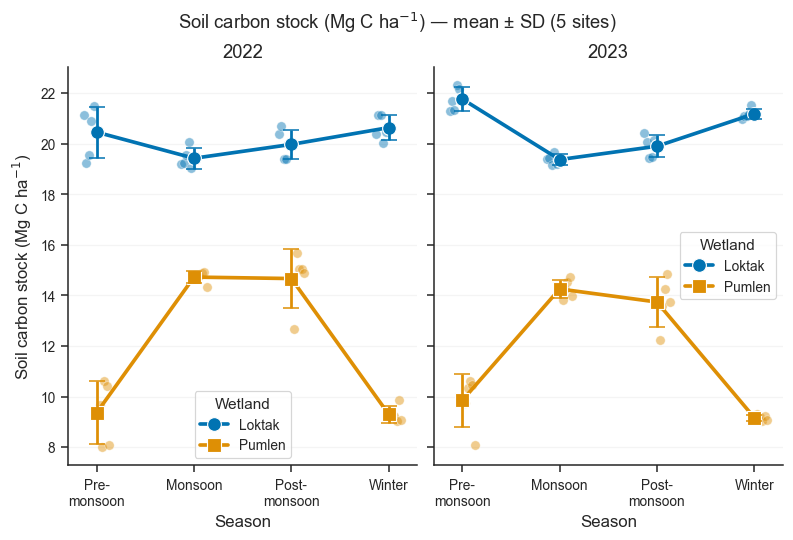

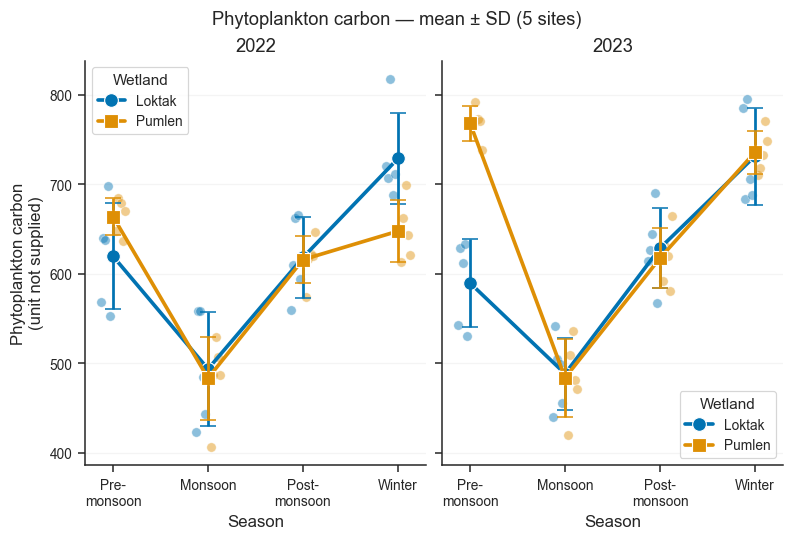

In [4]:
def seasonal_figure(variable):
    fig, axes = plt.subplots(1, 2, figsize=(7.1, 4.8), sharey=True, layout="constrained")
    for ax, year in zip(axes, [2022, 2023]):
        for lake in WETLANDS:
            raw = data.query("Wetland == @lake and Year == @year").copy()
            raw["Season_position"] = raw.Season.map(dict(zip(SEASONS, range(4))))
            # Fixed offsets only in categorical x: numeric measurements are unchanged.
            raw["Season_position"] += (raw.Site - 3)*0.025 + (-0.08 if lake == "Loktak" else 0.08)
            sns.scatterplot(data=raw, x="Season_position", y=variable,
                            color=PALETTE[lake], s=38, alpha=0.45, ax=ax, legend=False)
            group = seasonal.query("Variable == @variable and Wetland == @lake and Year == @year").set_index("Season").loc[SEASONS]
            x = np.arange(4)
            sns.lineplot(x=x, y=group.Mean.to_numpy(), color=PALETTE[lake],
                         marker="o" if lake == "Loktak" else "s", markersize=9,
                         linewidth=2.4, label=lake, ax=ax, errorbar=None)
            ax.errorbar(x, group.Mean, yerr=group.SD, fmt="none", capsize=5,
                        color=PALETTE[lake], linewidth=1.8)
        ax.set(title=str(year), xlabel="Season", xticks=range(4),
               xticklabels=["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"])
        set_numeric_axis(ax, "y", data[variable], variable)
        ax.grid(axis="y", alpha=0.2)
        ax.legend(title="Wetland")
    fig.suptitle(f"{LABELS[variable].split(chr(10))[0]} — mean ± SD (5 sites)", fontsize=12)
    save_show(fig, f"seasonal_{variable}")

seasonal_figure("Soil_stock")
seasonal_figure("Phyto_carbon")

### TBC: plot the supplied summary separately

Values below come only from `Line_Graph!F8:I11`. Error bars reproduce the supplied
“±” values, whose definition is **not stated**; they are not labelled as SD, SE or CI.
The raw TBC-labelled block is excluded. The unit follows the workbook's explicit
“Total Biomass Carbon (Mg C/ha)” heading and should be checked with the corrected data.

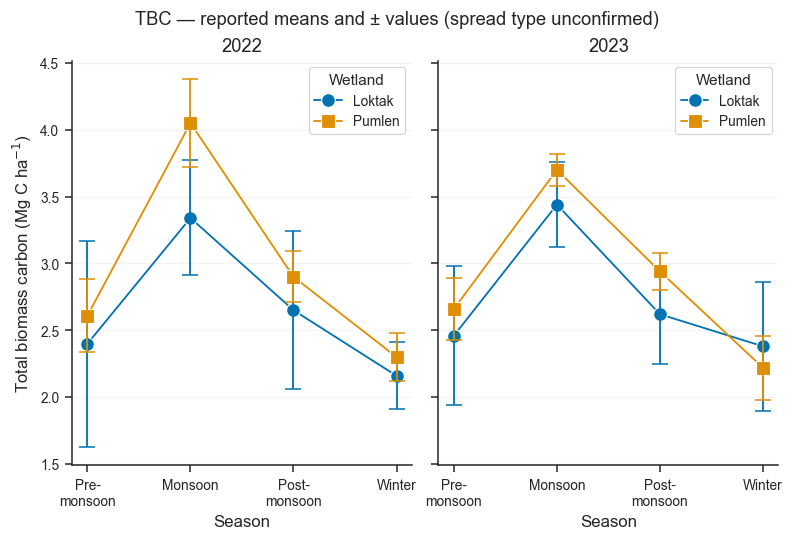

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.1, 4.8), sharey=True, layout="constrained")
for ax, year in zip(axes, [2022, 2023]):
    for lake in WETLANDS:
        group = reported.query("Variable == 'TBC' and Wetland == @lake and Year == @year").set_index("Season").loc[SEASONS]
        sns.lineplot(x=np.arange(4), y=group.Mean.to_numpy(), color=PALETTE[lake],
                     marker="o" if lake == "Loktak" else "s", markersize=9,
                     label=lake, errorbar=None, ax=ax)
        ax.errorbar(np.arange(4), group.Mean, yerr=group.Reported_spread,
                    fmt="none", capsize=5, color=PALETTE[lake])
    ax.set(title=str(year), xlabel="Season", ylabel=LABELS["TBC"], xticks=range(4),
           xticklabels=["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"])
    ax.legend(title="Wetland")
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("TBC — reported means and ± values (spread type unconfirmed)", fontsize=12)
save_show(fig, "seasonal_TBC_reported_only")

## 4. Environmental associations

Each point is one site–season–year record. Colour = lake; shape = season. Both years
are included. The panels show paired measurements, with no fitted causal model or
independence-based significance test. The next table separates pooled correlations
from within-lake correlations to expose possible group dependence.

SOC and bulk density can enter a soil-carbon-stock calculation. Their associations
with stock can therefore include mathematical coupling; the supplied files do not
establish an independent mechanism or provide the complete stock-calculation protocol.

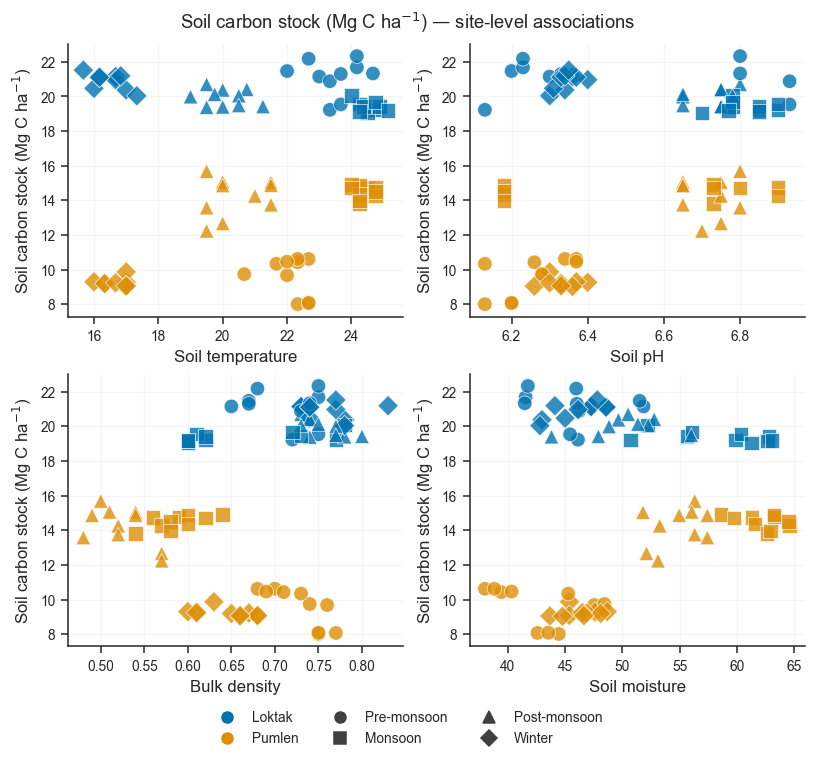

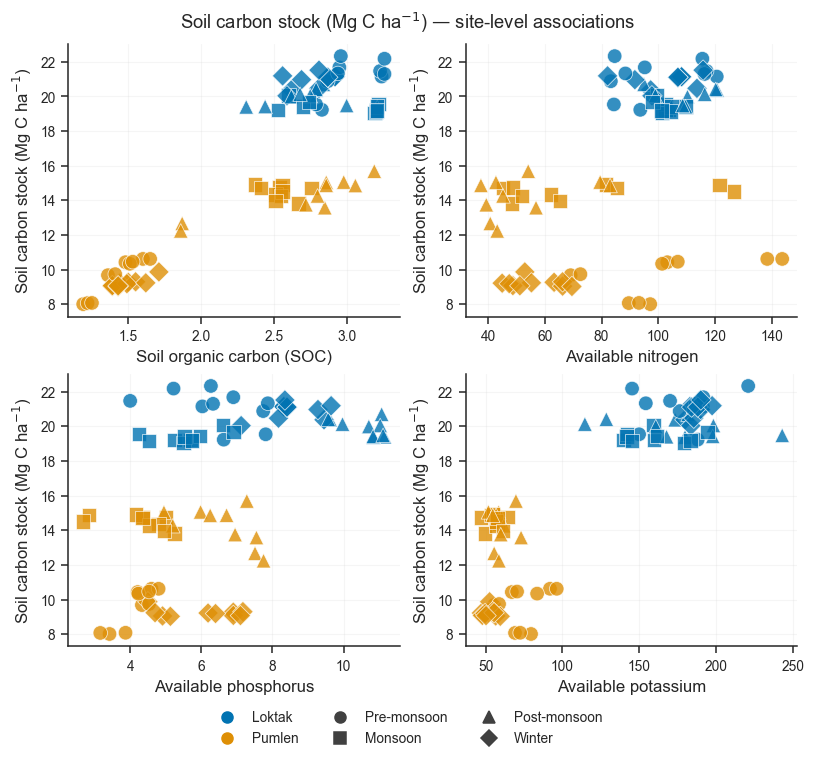

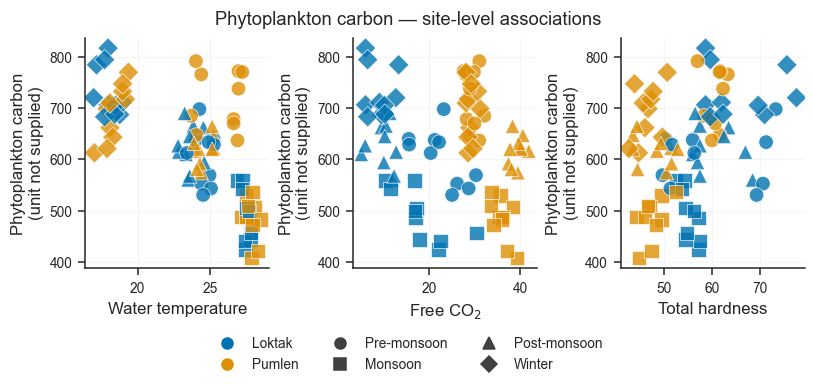

In [6]:
def scatter_panels(response, predictors, name, columns=2):
    rows = int(np.ceil(len(predictors)/columns))
    fig, axes = plt.subplots(rows, columns, figsize=(7.3, 3.4*rows),
                             squeeze=False, layout="constrained")
    for ax, predictor in zip(axes.flat, predictors):
        sns.scatterplot(data=data, x=predictor, y=response, hue="Wetland", style="Season",
                        hue_order=WETLANDS, style_order=SEASONS, palette=PALETTE,
                        markers=MARKERS, s=90, alpha=0.8, edgecolor="white",
                        linewidth=0.5, legend=False, ax=ax)
        set_numeric_axis(ax, "x", data[predictor], predictor)
        set_numeric_axis(ax, "y", data[response], response)
        ax.grid(alpha=0.18)
    for ax in list(axes.flat)[len(predictors):]: ax.set_visible(False)
    handles = [Line2D([], [], color=PALETTE[lake], marker="o", linestyle="", label=lake) for lake in WETLANDS]
    handles += [Line2D([], [], color="0.25", marker=MARKERS[s], linestyle="", label=s) for s in SEASONS]
    fig.legend(handles=handles, loc="outside lower center", ncol=3, frameon=False, markerscale=1.5)
    fig.suptitle(f"{LABELS[response].split(chr(10))[0]} — site-level associations", fontsize=12)
    save_show(fig, name)

soil_predictors = ["Soil_Temp", "Soil_pH", "BD", "Moisture", "SOC", "N", "P", "K"]
scatter_panels("Soil_stock", soil_predictors[:4], "soil_stock_physical")
scatter_panels("Soil_stock", soil_predictors[4:], "soil_stock_carbon_nutrients")
scatter_panels("Phyto_carbon", ["Water_Temp", "CO2", "Hardness"], "phytoplankton_associations", columns=3)

In [7]:
associations = []
for response, predictors in [("Soil_stock", soil_predictors),
                             ("Phyto_carbon", ["Water_Temp", "CO2", "Hardness"])]:
    for predictor in predictors:
        row = {"Response": response, "Predictor": predictor}
        for group, subset in [("Pooled (n=80)", data)] + [(lake+" (n=40)", data.query("Wetland == @lake")) for lake in WETLANDS]:
            row[group] = subset[[predictor, response]].corr().iloc[0, 1]
        associations.append(row)
associations = pd.DataFrame(associations)
display(associations.round(3))
associations.to_csv(TABLE_DIR / "pooled_and_within_lake_correlations.csv", index=False)

,Response,Predictor,Pooled (n=80),Loktak (n=40),Pumlen (n=40)
0,Soil_stock,Soil_Temp,0.146,-0.326,0.548
1,Soil_stock,Soil_pH,0.360,-0.547,0.674
2,Soil_stock,BD,0.345,0.240,-0.790
3,Soil_stock,Moisture,0.122,-0.631,0.834
4,Soil_stock,SOC,0.865,0.121,0.958
5,Soil_stock,N,0.510,0.005,-0.157
6,Soil_stock,P,0.539,-0.005,0.061
7,Soil_stock,K,0.863,0.239,-0.170
8,Phyto_carbon,Water_Temp,-0.661,-0.863,-0.500
9,Phyto_carbon,CO2,-0.245,-0.581,-0.597


## Reading the results

Compare lakes within the same season and year before interpreting pooled associations.
Within-lake correlations still combine repeated sites and seasonal changes. This notebook
does not fit adjusted regressions. For the full supplied correlation matrices use
**02_correlation_heatmaps.ipynb**; for environmental distributions and PCA use
**03_environment_and_pca.ipynb**.

## Conclusions and reporting guidance

- Interpret the seasonal profiles first: compare both wetlands **within the same year and season** rather than pooling away temporal structure. Error bars on the site-level series show **sample SD across five sites**, not confidence intervals or uncertainty in a long-term wetland mean.
- The workbook reports distinct seasonal patterns in **soil carbon stock**, with Loktak generally higher than Pumlen; seasonal contrasts should be assessed with site-aware models before claiming statistical significance.
- **TBC remains summary-only** until original per-site biomass values are recovered. Do not calculate regressions from the TBC-labelled block, which reproduces TDS.
- Scatterplots are exploratory associations. Differences between wetland groups or shared seasonal cycles may create apparent pooled correlations. If the thesis needs effect estimates, consider a mixed-effects model with site nested within wetland and season/year as fixed effects, subject to verifying the sampling design.
- Confirm sampling depth and dry bulk-density units for carbon-stock interpretation, and confirm the units of phytoplankton carbon and the meaning of the reported `±` values before figure submission.